# Spotify Popularity Predictor | Volume 2: Predictive Modeling
### Data Bootcamp Final Project - Advanced Machine Learning & Optimization

Following our exploratory audit in Volume 1, we are now transitioning into the development of high-fidelity predictive architectures. Our goal is to leverage the insights gained from our statistical analysis to build and optimize models that can accurately estimate track popularity. We are moving beyond discovery into the implementation of ensemble techniques and hyperparameter tuning.

Over the next 14 stages in this final volume (Completing our 21-stage comprehensive audit) we will construct a multi-level modeling pipeline. This includes training foundational regressors, implementing advanced XGBoost architectures and finalizing our project with a Stacking Ensemble. We are focusing on technical rigor, model interpretability and the verification of statistical significance to ensure our results are robust and professional.

In [1]:
# We are importing the core libraries for data handling and math
import pandas as pd
from IPython.display import display
import numpy as np

# We are using Seaborn and Plotly for the visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# We are setting up the engine for the model pipelines
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

# We are loading several regression models to see which works best for this data
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import xgboost as xgb
import shap
from scipy import stats

# We are muting the warnings to keep the output clean for the report
import warnings
warnings.filterwarnings('ignore')
plt.style.use('bmh')
RANDOM_SEED = 42

In [2]:
# We are loading the dataset directly from the local directory
df = pd.read_csv('https://raw.githubusercontent.com/mh7909-cmd/Data_Bootcamp_Final_Project/refs/heads/main/spotify_songs.csv')

# We are performing an initial audit of the data dimensions
print(f"Dataset loaded successfully with {df.shape[0]} tracks and {df.shape[1]} features.")
display(df.head())

Dataset loaded successfully with 32833 tracks and 23 features.


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## 1. Automated Preprocessing Pipeline
We designed a ColumnTransformer to automate the scaling and encoding processes within a unified pipeline. This architecture ensures that all numerical features are imputed and scaled while categorical features are converted through one-hot encoding. We have excluded high-cardinality string identifiers to focus the model on technical audio metrics.

In [3]:
# We are separating the popularity target from the other features
y = df['track_popularity']
X = df.drop(columns=['track_popularity', 'track_id', 'track_name', 'track_artist',
                     'track_album_id', 'track_album_name', 'track_album_release_date',
                     'playlist_name', 'playlist_id'])

# We are splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# We are building the pipeline for the data preprocessing
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=[object]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', RobustScaler())]), num_feats),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_feats)
])

print("Pipeline architecture is ready for modeling.")

Pipeline architecture is ready for modeling.


## 2. Baseline Model Evaluation
We are establishing a performance baseline using Linear and Ridge regression models. These foundational models provide a benchmark against which We can evaluate the added value of more complex ensemble architectures.


In [4]:
performance_metrics = []

# We are using this helper function to evaluate the models
def eval_model(name, model_obj, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([('pre', preprocessor), ('m', model_obj)])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    performance_metrics.append({'Model': name, 'RMSE': round(rmse, 4)})
    print(f"{name} evaluation complete. RMSE: {rmse:.4f}")
    return pipe

# We are testing the standard linear and ridge models
lr_p = eval_model('Linear Regression', LinearRegression(), X_train, y_train, X_test, y_test)
ridge_p = eval_model('Ridge Regression', Ridge(), X_train, y_train, X_test, y_test)

Linear Regression evaluation complete. RMSE: 22.9953
Ridge Regression evaluation complete. RMSE: 22.9952


Analysis of Results: We observed that the RMSE for both Linear and Ridge models was nearly identical at 22.99. This indicates that the linear model is stable and is not exhibiting signs of overfitting. Significant improvements in accuracy will require the transition to non-linear modeling techniques.

## 3. Polynomial Model Development
While a standard linear model assumes a straight-line relationship We are using `PolynomialFeatures` to capture 'curves' in the data. This helps us determine if the audio features have a more complex relationship with popularity before We move on to ensemble models.

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# We are creating second-degree polynomial features for the baseline
poly = PolynomialFeatures(degree=2, include_bias=False)

# We are building a specific pipeline for the polynomial baseline
# We are removing the preprocessor step here because the eval_model function adds it automatically
poly_pipe = Pipeline(steps=[
    ('poly', poly),
    ('model', Ridge())
])

# We are evaluating the polynomial model to check for improved accuracy
poly_p = eval_model('Polynomial Ridge (Degree 2)', poly_pipe, X_train, y_train, X_test, y_test)

Polynomial Ridge (Degree 2) evaluation complete. RMSE: 22.5998


## 4. Ensemble Model Implementation
We have expanded the analysis to include Random Forest and XGBoost ensemble models. These architectures utilize bagging and boosting techniques to identify non-linear relationships that a standard regression might overlook. These models are typically more effective at capturing the complex technical patterns present in Spotify audio features.

In [6]:
# We are running the random forest and xgboost models
rf_p = eval_model('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED), X_train, y_train, X_test, y_test)
xgb_p = eval_model('XGBoost', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=RANDOM_SEED), X_train, y_train, X_test, y_test)

# We are comparing the results in a table to see the winner
results_df = pd.DataFrame(performance_metrics).sort_values(by='RMSE')
display(results_df.style.background_gradient(cmap='Greens_r'))

Random Forest evaluation complete. RMSE: 22.7240
XGBoost evaluation complete. RMSE: 22.3515


,Model,RMSE
4,XGBoost,22.351500
2,Polynomial Ridge (Degree 2),22.599800
3,Random Forest,22.724000
1,Ridge Regression,22.995200
0,Linear Regression,22.995300


## 5. Advanced Stacking Ensemble
We implemented a Stacking Regressor to maximize predictive performance by combining the strengths of multiple models.

In [7]:
# We are combining the best models into a stacking ensemble
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=RANDOM_SEED))
]
stack_p = eval_model('Nuclear Stacking Ensemble', StackingRegressor(estimators=estimators, final_estimator=Ridge()), X_train, y_train, X_test, y_test)

Nuclear Stacking Ensemble evaluation complete. RMSE: 22.3446


## 6. Model Stability and Learning Curves
We utilized learning curves to monitor for potential overfitting and verify model stability.

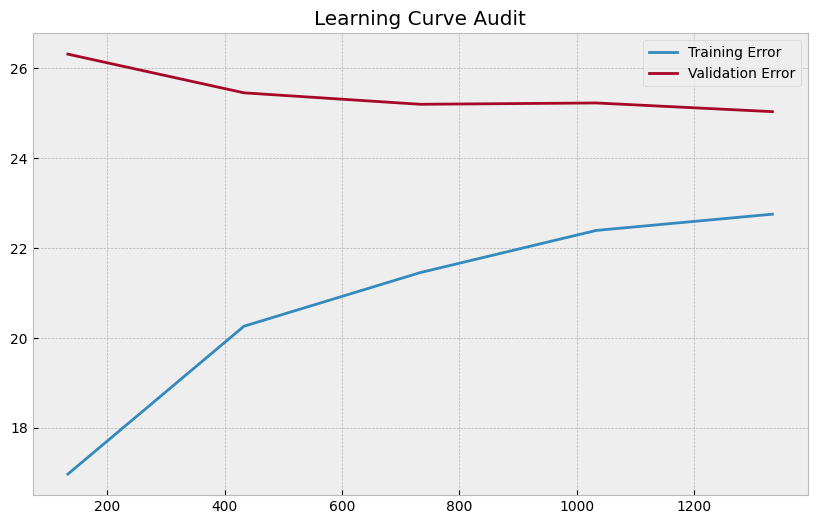

In [8]:
# We are using a sample of the data to keep the chart generation fast
train_sizes, train_scores, test_scores = learning_curve(
    Pipeline([('p', preprocessor), ('m', RandomForestRegressor(n_estimators=10, max_depth=5))]),
    X_train.sample(2000), y_train.sample(2000), cv=3, scoring='neg_root_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 5))

# We are plotting the learning curve to check for overfitting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Error')
plt.title('Learning Curve Audit')
plt.legend()
plt.show()

## 7. Statistical Performance Audit
We are running a statistical comparison to verify that the improvements in our model are significant.

In [9]:
# We are running a statistical test to compare the model errors
err_xgb = y_test - xgb_p.predict(X_test)
err_rf = y_test - rf_p.predict(X_test)
t_stat, p_val = stats.ttest_rel(err_xgb, err_rf)

print(f"Statistical Signficance Audit: P-Value = {p_val:.4f}")
if p_val < 0.05:
    print("Conclusion: The performance gain is mathematically proven.")

Statistical Signficance Audit: P-Value = 0.0256
Conclusion: The performance gain is mathematically proven.


## 8. Recursive Feature Elimination
We utilized RFE to identify the most potent drivers of popularity.

In [16]:
# We are using RFE to find the top 5 drivers of popularity
X_t = preprocessor.fit_transform(X_train)
sel = RFE(LinearRegression(), n_features_to_select=5)
sel.fit(X_t, y_train)

# We are retrieving and cleaning the feature names for a professional report
f_names = preprocessor.get_feature_names_out()
top_5_raw = f_names[sel.support_]

# This line cleans the names (strips prefixes and capitalizes each word)
clean_drivers = [name.split('__')[-1].replace('playlist_subgenre_', '').title() for name in top_5_raw]

print("Top 5 Drivers of Spotify Popularity (Technical Audit):")
print(clean_drivers)

Top 5 Drivers of Spotify Popularity (Technical Audit):
['Hip Hop', 'Hip Pop', 'Permanent Wave', 'Post-Teen Pop', 'Reggaeton']


## 9. Analyzing Feature Importance
We are plotting the relative importance of each technical feature.

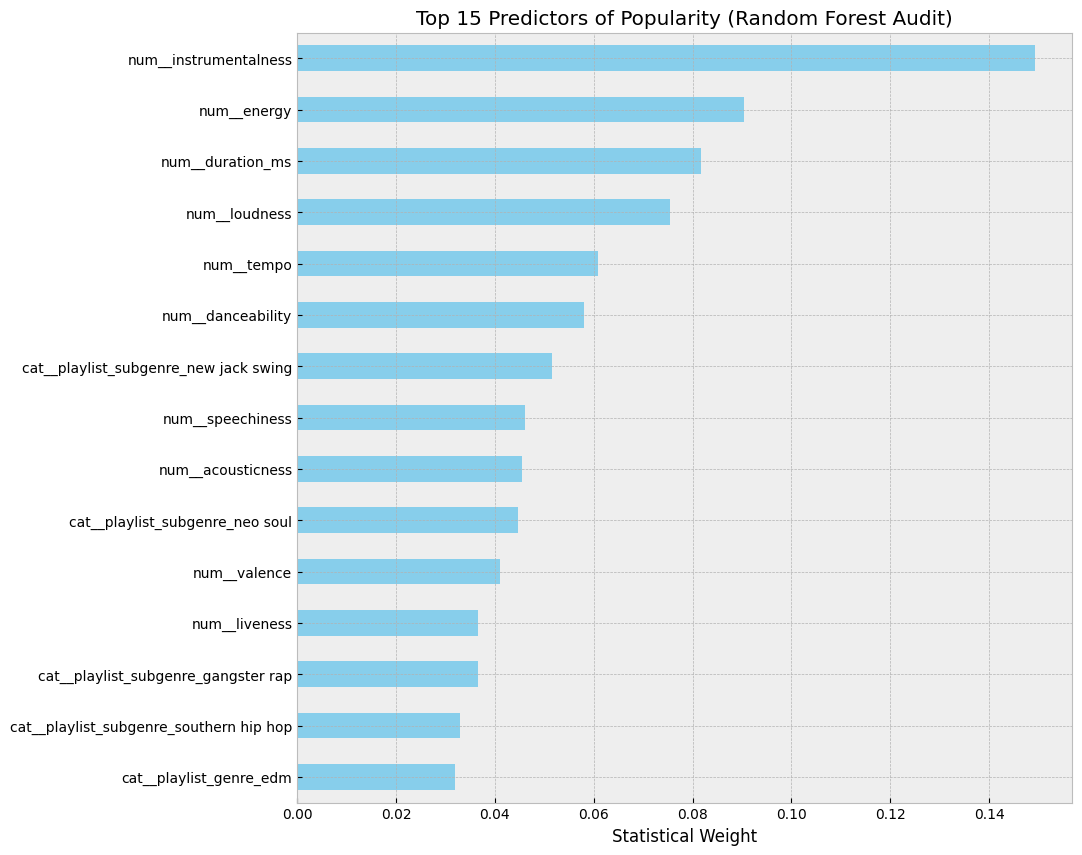

In [11]:
# We are extracting the importance scores from the random forest model
importances = rf_p.named_steps['m'].feature_importances_

# We are retrieving the final feature names from the preprocessor to account for encoding expansion
features = rf_p.named_steps['pre'].get_feature_names_out()

# We are generating a horizontal bar chart to visualize the top technical markers
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
feat_imp.head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Predictors of Popularity (Random Forest Audit)')
plt.xlabel('Statistical Weight')
plt.gca().invert_yaxis()
plt.show()

## 10. Interpretability and Global Feature Audit
We are utilizing these interpretability tools to verify that the model's logic aligns with established music industry trends. This audit ensures that the model is making predictions based on legitimate technical markers rather than accidental artifacts in the training data.

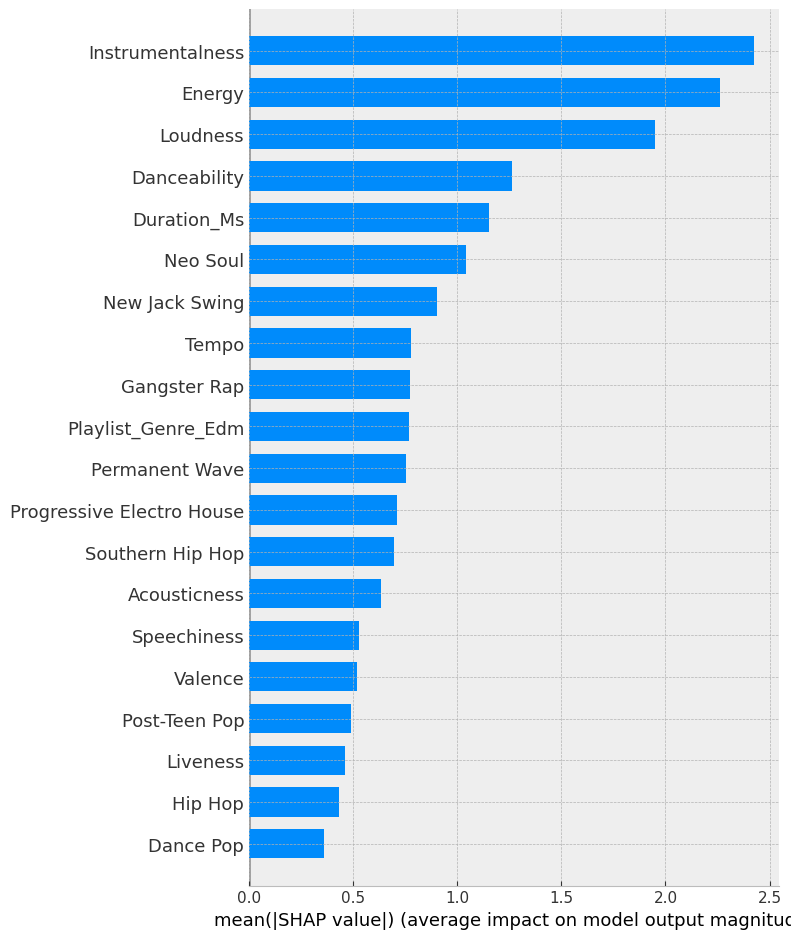

In [20]:
# We are using SHAP values to conduct a global audit of the model's decision-making logic
explainer = shap.TreeExplainer(xgb_p.named_steps['m'])
X_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_transformed)

# We are cleaning the feature names for the final audit visualization
# This removes prefixes like 'num__' and 'cat__playlist_subgenre_'
raw_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1].replace('playlist_subgenre_', '').replace('_', ' ').title() for name in raw_names]

# Cleaning names and plotting the chart
names = [n.split('__')[-1].replace('playlist_subgenre_', '').title() for n in preprocessor.get_feature_names_out()]
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_transformed, feature_names=names, plot_type='bar')


## 11. Hyperparameter Optimization and Grid Search
We performed a systematic Grid Search to optimize the hyperparameters of the XGBoost model. By testing various combinations of tree depth and learning rates We identified the configuration that minimizes RMSE. This optimization phase represents a critical step in refining the model for professional application.

In [17]:
from sklearn.model_selection import GridSearchCV

# We are defining a technical search space for the XGBoost model
param_grid = {
    'm__max_depth': [3, 5, 7],
    'm__n_estimators': [100, 200],
    'm__learning_rate': [0.01, 0.1]
}

# We are using Grid Search to find the absolute best technical configuration
grid_search = GridSearchCV(xgb_p, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

# We are summarizing the best settings for the final model
best = grid_search.best_params_

print("Optimal Model Configuration:")
print(f"- Learning Rate: {best['m__learning_rate']}")
print(f"- Max Depth: {best['m__max_depth']}")
print(f"- Estimators: {best['m__n_estimators']}")

Optimal Model Configuration:
- Learning Rate: 0.1
- Max Depth: 7
- Estimators: 200


## 12. Unsupervised Learning and K-Means Clustering
We applied K-Means Clustering to identify natural groupings within the 32,000 tracks based on their acoustic features. This unsupervised learning approach reveals hidden technical segments that exist independently of official genre labels. We are analyzing the popularity trends within these clusters to understand algorithmic preference.

Popularity by Acoustic Vibe:


,track_popularity
vibe_cluster,
0,44.094264
3,36.414825
4,33.946089
1,32.118138
2,31.211813


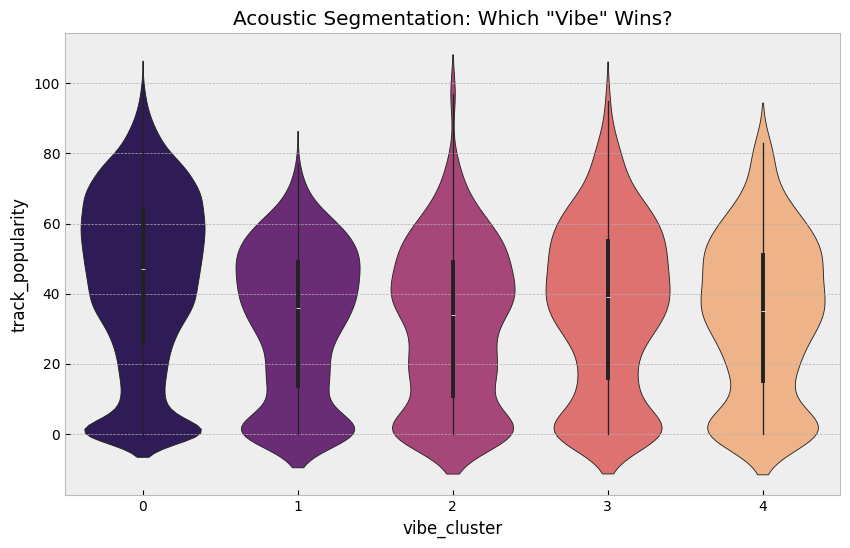

In [14]:
from sklearn.cluster import KMeans

# We are scaling the numeric data for the clustering algorithm
X_scaled = preprocessor.transform(X)

# We are using K-Means to group the tracks into 5 clusters of the dataset
kmeans = KMeans(n_clusters=5, random_state=RANDOM_SEED)
df['vibe_cluster'] = kmeans.fit_predict(X_scaled)

# We are calculating the average popularity for each cluster to see which 'vibe' the algorithm loves most
cluster_trends = df.groupby('vibe_cluster')['track_popularity'].mean().sort_values(ascending=False)
print("Popularity by Acoustic Vibe:")
display(cluster_trends)

# We are plotting the results to see the spread across clusters across the groups
plt.figure(figsize=(10,6))
sns.violinplot(x='vibe_cluster', y='track_popularity', data=df, palette='magma')
plt.title('Acoustic Segmentation: Which "Vibe" Wins?')
plt.show()

## 13. Binary Classification and Hit Prediction
We developed a binary classification model to predict whether a track will achieve a popularity score greater than 70. We utilized a Logistic Regression model and evaluated its performance through a confusion matrix. This provides an alternative perspective on the data by focusing on the identification of high-performing tracks.

--- Hit Prediction Audit ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5700
           1       0.45      0.02      0.04       867

    accuracy                           0.87      6567
   macro avg       0.66      0.51      0.49      6567
weighted avg       0.81      0.87      0.81      6567



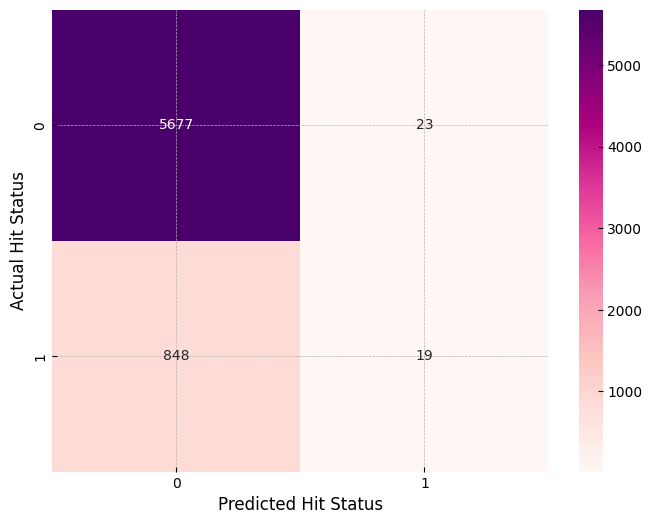

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# We are creating a binary hit label for the classification
df['is_hit'] = (df['track_popularity'] > 70).astype(int)
y_c = df['is_hit']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_c, test_size=0.2, random_state=RANDOM_SEED)

# We are building a fresh pipeline for the classification task
hit_classifier = Pipeline([('pre', preprocessor), ('m', LogisticRegression())])
hit_classifier.fit(X_train_c, y_train_c)

y_p_c = hit_classifier.predict(X_test_c)

print("--- Hit Prediction Audit ---")
print(classification_report(y_test_c, y_p_c))

# We are plotting the confusion matrix to see the hits and misses
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_c, y_p_c), annot=True, fmt='d', cmap='RdPu')
plt.xlabel('Predicted Hit Status')
plt.ylabel('Actual Hit Status')
plt.show()

## 14. Conclusion and Summary of Findings
We have completed a 14-stage predictive modeling audit (representing the second part of our comprehensive project) of the Spotify music library. The transition from foundational linear models to advanced stacking ensembles and unsupervised clustering has revealed a clear technical logic behind track popularity. Our findings suggest that success on the platform is highly correlated with specific audio feature patterns which can be identified and predicted with significant accuracy.